<a href="https://colab.research.google.com/github/tajmahal226/AI-Research-SKILLs-taj/blob/main/hardware_trends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of data points used for trend analysis: 157


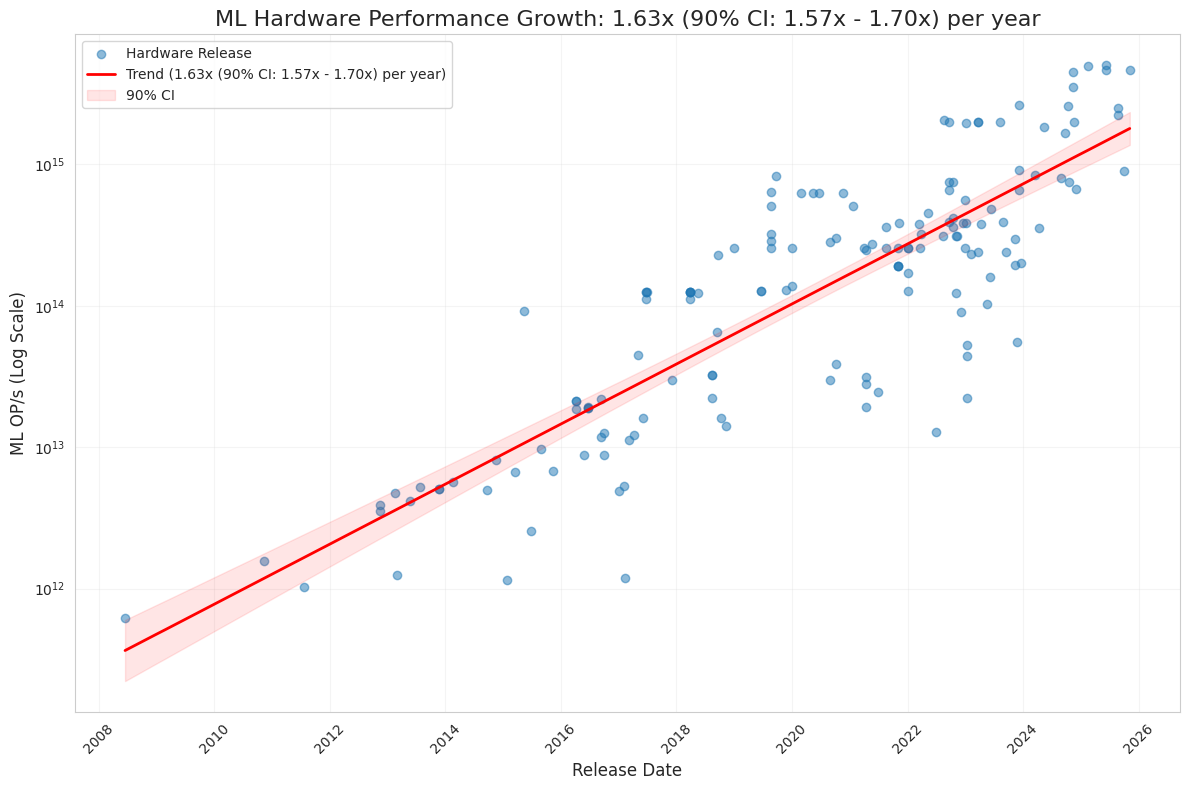

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import scipy.stats as stats

def plot_ml_hardware_growth(file_path):
    df = pd.read_csv(file_path)
    df['Release date'] = pd.to_datetime(df['Release date'], errors='coerce')
    df['ML OP/s'] = pd.to_numeric(df['ML OP/s'], errors='coerce')
    df_clean = df.dropna(subset=['Release date', 'ML OP/s']).copy()
    df_clean = df_clean[df_clean['ML OP/s'] > 0]

    if df_clean.empty:
        print("No valid data found to plot.")
        return

    def to_year_fraction(date):
        start = datetime(date.year, 1, 1)
        year_duration = (datetime(date.year + 1, 1, 1) - start).total_seconds()
        return date.year + (date - start).total_seconds() / year_duration

    df_clean['Year_Decimal'] = df_clean['Release date'].apply(to_year_fraction)
    x = df_clean['Year_Decimal'].values
    y_log = np.log10(df_clean['ML OP/s'].values)

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y_log)

    growth_rate = 10 ** slope
    n = len(x)
    print(f"Number of data points used for trend analysis: {n}")

    t_score = stats.t.ppf(1 - 0.05, df=n-2)
    growth_rate_lower = 10 ** (slope - t_score * std_err)
    growth_rate_upper = 10 ** (slope + t_score * std_err)
    growth_str = f"{growth_rate:.2f}x (90% CI: {growth_rate_lower:.2f}x - {growth_rate_upper:.2f}x) per year"

    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(12, 8))

    ax.scatter(df_clean['Release date'], y_log, alpha=0.5, label='Hardware Release')

    x_range_years = np.linspace(x.min(), x.max(), 100)
    y_pred_log = slope * x_range_years + intercept

    def decimal_year_to_dt(dec_year):
        year = int(dec_year)
        rem = dec_year - year
        base = datetime(year, 1, 1)
        seconds = rem * 365.25 * 24 * 3600
        return base + pd.Timedelta(seconds=seconds)

    x_range_dt = [decimal_year_to_dt(dy) for dy in x_range_years]

    y_hat_sample = slope * x + intercept
    s_err = np.sqrt(np.sum((y_log - y_hat_sample) ** 2) / (n - 2))
    x_mean = np.mean(x)
    sum_squares_x = np.sum((x - x_mean) ** 2)
    ci_width = t_score * s_err * np.sqrt(1/n + (x_range_years - x_mean)**2 / sum_squares_x)

    ax.plot(x_range_dt, y_pred_log, color='red', linewidth=2, label=f'Trend ({growth_str})')
    ax.fill_between(x_range_dt, y_pred_log - ci_width, y_pred_log + ci_width, color='red', alpha=0.1, label='90% CI')

    ax.set_xlabel('Release Date', fontsize=12)
    ax.set_ylabel('ML OP/s (Log Scale)', fontsize=12)
    ax.set_title(f'ML Hardware Performance Growth: {growth_str}', fontsize=16)

    def log_tick_formatter(val, pos):
        return f"$10^{{{int(val)}}}$"
    ax.yaxis.set_major_formatter(plt.FuncFormatter(log_tick_formatter))

    plt.legend(loc='upper left')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_ml_hardware_growth('ML Hardware.csv')

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from datetime import datetime
import scipy.stats as stats

def plot_ml_price_performance_growth(file_path):
    # 1. Load and Clean Data
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return

    print(f"Total rows in file: {len(df)}")

    if 'Release price (USD)' not in df.columns:
        print(f"Error: Column 'Release price (USD)' not found. Available columns: {df.columns.tolist()}")
        return

    # Clean Columns
    df['Release date'] = pd.to_datetime(df['Release date'], errors='coerce')
    df['ML OP/s'] = pd.to_numeric(df['ML OP/s'], errors='coerce')

    # SPECIAL HANDLING FOR PRICE: Remove '$' and ','
    df['Release price (USD)'] = df['Release price (USD)'].astype(str).str.replace(r'[$,]', '', regex=True)
    df['Release price (USD)'] = pd.to_numeric(df['Release price (USD)'], errors='coerce')

    # Calculate Performance per Dollar
    df['Release price (USD)'] = df['Release price (USD)'].replace(0, np.nan)
    df['Perf_per_Dollar'] = df['ML OP/s'] / df['Release price (USD)']

    # Filter valid rows
    df_clean = df.dropna(subset=['Release date', 'ML OP/s', 'Release price (USD)', 'Perf_per_Dollar']).copy()
    df_clean = df_clean[df_clean['Perf_per_Dollar'] > 0]

    if df_clean.empty:
        print("No valid data found.")
        return

    # 2. Regression Analysis
    def to_year_fraction(date):
        start = datetime(date.year, 1, 1)
        year_duration = (datetime(date.year + 1, 1, 1) - start).total_seconds()
        return date.year + (date - start).total_seconds() / year_duration

    df_clean['Year_Decimal'] = df_clean['Release date'].apply(to_year_fraction)
    x = df_clean['Year_Decimal'].values
    y_log = np.log10(df_clean['Perf_per_Dollar'].values)

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y_log)

    growth_rate = 10 ** slope
    n = len(x)

    t_score = stats.t.ppf(1 - 0.05, df=n-2)
    growth_rate_lower = 10 ** (slope - t_score * std_err)
    growth_rate_upper = 10 ** (slope + t_score * std_err)
    growth_str = f"{growth_rate:.2f}x (90% CI: {growth_rate_lower:.2f}x - {growth_rate_upper:.2f}x) per year"

    print(f"--- Price-Performance Statistics ---")
    print(f"Count: {n}")
    print(f"Growth: {growth_str}")
    print(f"------------------------------------")

    # 3. Interactive Plotting with Plotly

    # Prepare Regression Line Data
    x_range_years = np.linspace(x.min(), x.max(), 100)
    y_pred_log = slope * x_range_years + intercept

    # Calculate CI Bounds (Log scale)
    y_hat_sample = slope * x + intercept
    s_err = np.sqrt(np.sum((y_log - y_hat_sample) ** 2) / (n - 2))
    x_mean = np.mean(x)
    sum_squares_x = np.sum((x - x_mean) ** 2)
    ci_width = t_score * s_err * np.sqrt(1/n + (x_range_years - x_mean)**2 / sum_squares_x)

    # Convert Regression/CI back to Linear scale for Plotly (since we use log-axis)
    y_pred_linear = 10 ** y_pred_log
    lower_bound_linear = 10 ** (y_pred_log - ci_width)
    upper_bound_linear = 10 ** (y_pred_log + ci_width)

    # Convert x_range back to datetime for plotting
    def decimal_year_to_dt(dec_year):
        year = int(dec_year)
        rem = dec_year - year
        base = datetime(year, 1, 1)
        seconds = rem * 365.25 * 24 * 3600
        return base + pd.Timedelta(seconds=seconds)

    x_range_dt = [decimal_year_to_dt(dy) for dy in x_range_years]

    fig = go.Figure()

    # A. Add Confidence Interval (Shaded Area)
    # We create a closed shape by going Forward on Upper, then Backward on Lower
    fig.add_trace(go.Scatter(
        x=np.concatenate([x_range_dt, x_range_dt[::-1]]),
        y=np.concatenate([upper_bound_linear, lower_bound_linear[::-1]]),
        fill='toself',
        fillcolor='rgba(0, 128, 0, 0.1)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        showlegend=True,
        name='90% CI'
    ))

    # B. Add Regression Line
    fig.add_trace(go.Scatter(
        x=x_range_dt,
        y=y_pred_linear,
        mode='lines',
        line=dict(color='darkgreen', width=3),
        name=f'Trend ({growth_str})',
        hoverinfo="skip"
    ))

    # C. Add Data Points (Scatter) with Hover Data
    fig.add_trace(go.Scatter(
        x=df_clean['Release date'],
        y=df_clean['Perf_per_Dollar'],
        mode='markers',
        marker=dict(color='green', size=8, opacity=0.6),
        name='Hardware',
        text=df_clean['Hardware name'], # Primary hover text
        # Pass extra data for hover template
        customdata=np.stack((
            df_clean['ML OP/s'],
            df_clean['Release price (USD)']
        ), axis=-1),
        hovertemplate=(
            "<b>%{text}</b><br>" +
            "Date: %{x|%Y-%m-%d}<br>" +
            "Perf/$: %{y:.2e} OP/s/$<br>" +
            "ML OP/s: %{customdata[0]:.2e}<br>" +
            "Price: $%{customdata[1]:,.2f}<br>" +
            "<extra></extra>" # Hides the secondary box
        )
    ))

    # Layout Config
    fig.update_layout(
        title=f'ML Hardware Price-Performance Growth: {growth_str}',
        xaxis_title='Release Date',
        yaxis=dict(
            title='ML OP/s per Dollar (Log Scale)',
            type="log",
            dtick=1,                # Force a tick mark at every power of 10
            exponentformat="power"  # Render as 10^x (e.g., 10^9)
        ),
        template="plotly_white",
        height=700,
        hovermode="closest"
    )

    fig.show()

plot_ml_price_performance_growth('ML Hardware.csv')

Total rows in file: 169
--- Price-Performance Statistics ---
Count: 53
Growth: 1.45x (90% CI: 1.36x - 1.54x) per year
------------------------------------


In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from datetime import datetime
import scipy.stats as stats

def plot_bandwidth_growth(file_path):
    # 1. Load and Clean Data
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return

    # Define columns
    date_col = 'Release date'
    y_col_raw = 'Memory bandwidth (byte/s)' # The column name in the CSV
    name_col = 'Hardware name'

    # Check if columns exist
    if y_col_raw not in df.columns:
        print(f"Error: Column '{y_col_raw}' not found. Available columns: {df.columns.tolist()}")
        return

    # Clean Columns
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    # Remove symbols like ',' or '$' and convert to numeric
    df[y_col_raw] = df[y_col_raw].astype(str).str.replace(r'[,]', '', regex=True)
    df[y_col_raw] = pd.to_numeric(df[y_col_raw], errors='coerce')

    # Filter valid rows
    df_clean = df.dropna(subset=[date_col, y_col_raw]).copy()
    df_clean = df_clean[df_clean[y_col_raw] > 0]

    if df_clean.empty:
        print("No valid data found.")
        return

    # --- CONVERT TO GB/s ---
    # 1 GB = 10^9 bytes (standard for bandwidth specs)
    df_clean['Bandwidth_GBs'] = df_clean[y_col_raw] / 1e9
    y_col = 'Bandwidth_GBs' # Update the y_col variable to point to the new column

    # 2. Regression Analysis
    def to_year_fraction(date):
        start = datetime(date.year, 1, 1)
        year_duration = (datetime(date.year + 1, 1, 1) - start).total_seconds()
        return date.year + (date - start).total_seconds() / year_duration

    df_clean['Year_Decimal'] = df_clean[date_col].apply(to_year_fraction)
    x = df_clean['Year_Decimal'].values
    y_log = np.log10(df_clean[y_col].values)

    # Perform Linear Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y_log)

    growth_rate = 10 ** slope
    n = len(x)

    # Calculate 90% CI for the growth rate
    t_score = stats.t.ppf(1 - 0.05, df=n-2)
    growth_rate_lower = 10 ** (slope - t_score * std_err)
    growth_rate_upper = 10 ** (slope + t_score * std_err)
    growth_str = f"{growth_rate:.2f}x (90% CI: {growth_rate_lower:.2f}x - {growth_rate_upper:.2f}x) per year"

    # Print Statistics
    print(f"--- Memory Bandwidth Statistics ---")
    print(f"Count (n): {n}")
    print(f"Date Range: {df_clean[date_col].min().year} to {df_clean[date_col].max().year}")
    print(f"Growth Rate: {growth_rate:.2f}x/year")
    print(f"90% CI: {growth_rate_lower:.2f}x - {growth_rate_upper:.2f}x")
    print(f"-----------------------------------")

    # 3. Interactive Plotting with Plotly

    # Prepare Regression Line Data
    x_range_years = np.linspace(x.min(), x.max(), 100)
    y_pred_log = slope * x_range_years + intercept

    # Calculate CI Bounds (Log scale)
    y_hat_sample = slope * x + intercept
    s_err = np.sqrt(np.sum((y_log - y_hat_sample) ** 2) / (n - 2))
    x_mean = np.mean(x)
    sum_squares_x = np.sum((x - x_mean) ** 2)
    ci_width = t_score * s_err * np.sqrt(1/n + (x_range_years - x_mean)**2 / sum_squares_x)

    # Convert Regression/CI back to Linear scale
    y_pred_linear = 10 ** y_pred_log
    lower_bound_linear = 10 ** (y_pred_log - ci_width)
    upper_bound_linear = 10 ** (y_pred_log + ci_width)

    # Convert x_range back to datetime for plotting
    def decimal_year_to_dt(dec_year):
        year = int(dec_year)
        rem = dec_year - year
        base = datetime(year, 1, 1)
        seconds = rem * 365.25 * 24 * 3600
        return base + pd.Timedelta(seconds=seconds)

    x_range_dt = [decimal_year_to_dt(dy) for dy in x_range_years]

    fig = go.Figure()

    # A. Add Confidence Interval (Shaded Area)
    fig.add_trace(go.Scatter(
        x=np.concatenate([x_range_dt, x_range_dt[::-1]]),
        y=np.concatenate([upper_bound_linear, lower_bound_linear[::-1]]),
        fill='toself',
        fillcolor='rgba(0, 0, 255, 0.1)', # Blue tint
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        showlegend=True,
        name='90% CI'
    ))

    # B. Add Regression Line
    fig.add_trace(go.Scatter(
        x=x_range_dt,
        y=y_pred_linear,
        mode='lines',
        line=dict(color='blue', width=3),
        name=f'Trend ({growth_str})',
        hoverinfo="skip"
    ))

    # C. Add Data Points (Scatter)
    fig.add_trace(go.Scatter(
        x=df_clean[date_col],
        y=df_clean[y_col],
        mode='markers',
        marker=dict(color='dodgerblue', size=8, opacity=0.6),
        name='Hardware',
        text=df_clean[name_col],
        customdata=df_clean[y_col],
        hovertemplate=(
            "<b>%{text}</b><br>" +
            "Date: %{x|%Y-%m-%d}<br>" +
            "Bandwidth: %{y:.2f} GB/s<br>" +  # Changed to .2f for cleaner GB display
            "<extra></extra>"
        )
    ))

    # Layout Config
    fig.update_layout(
        title=f'Memory Bandwidth Growth: {growth_str}',
        xaxis_title='Release Date',
        yaxis_title='Memory Bandwidth (GB/s) [Log Scale]', # Updated Title
        yaxis_type="log",
        template="plotly_white",
        height=700,
        hovermode="closest"
    )

    fig.show()

plot_bandwidth_growth('ML Hardware.csv')

--- Memory Bandwidth Statistics ---
Count (n): 147
Date Range: 2008 to 2025
Growth Rate: 1.28x/year
90% CI: 1.24x - 1.33x
-----------------------------------


In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from datetime import datetime
import scipy.stats as stats
import math

def plot_energy_efficiency_growth(file_path):
    # 1. Load and Clean Data
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return

    # Define columns
    date_col = 'Release date'
    perf_col = 'ML OP/s'
    power_col = 'TDP (W)'
    name_col = 'Hardware name'

    # Check if columns exist
    for col in [date_col, perf_col, power_col]:
        if col not in df.columns:
            print(f"Error: Column '{col}' not found. Available columns: {df.columns.tolist()}")
            return

    # Clean Columns
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df[perf_col] = pd.to_numeric(df[perf_col], errors='coerce')
    df[power_col] = pd.to_numeric(df[power_col], errors='coerce')

    # Calculate Efficiency (Perf / Watt)
    # Avoid division by zero
    df[power_col] = df[power_col].replace(0, np.nan)
    df['Efficiency'] = df[perf_col] / df[power_col]

    # Filter valid rows
    df_clean = df.dropna(subset=[date_col, 'Efficiency']).copy()
    df_clean = df_clean[df_clean['Efficiency'] > 0]

    if df_clean.empty:
        print("No valid data found.")
        return

    # 2. Regression Analysis
    def to_year_fraction(date):
        start = datetime(date.year, 1, 1)
        year_duration = (datetime(date.year + 1, 1, 1) - start).total_seconds()
        return date.year + (date - start).total_seconds() / year_duration

    df_clean['Year_Decimal'] = df_clean[date_col].apply(to_year_fraction)
    x = df_clean['Year_Decimal'].values
    y_log = np.log10(df_clean['Efficiency'].values)

    # Perform Linear Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y_log)

    growth_rate = 10 ** slope
    n = len(x)

    # Calculate 90% CI for the growth rate
    t_score = stats.t.ppf(1 - 0.05, df=n-2)
    growth_rate_lower = 10 ** (slope - t_score * std_err)
    growth_rate_upper = 10 ** (slope + t_score * std_err)
    growth_str = f"{growth_rate:.2f}x (90% CI: {growth_rate_lower:.2f}x - {growth_rate_upper:.2f}x) per year"

    # Print Statistics
    print(f"--- Energy Efficiency Statistics ---")
    print(f"Count (n): {n}")
    print(f"Date Range: {df_clean[date_col].min().year} to {df_clean[date_col].max().year}")
    print(f"Growth Rate: {growth_rate:.2f}x/year")
    print(f"90% CI: {growth_rate_lower:.2f}x - {growth_rate_upper:.2f}x")
    print(f"------------------------------------")

    # 3. Interactive Plotting with Plotly

    # Prepare Regression Line Data
    x_range_years = np.linspace(x.min(), x.max(), 100)
    y_pred_log = slope * x_range_years + intercept

    # Calculate CI Bounds (Log scale)
    y_hat_sample = slope * x + intercept
    s_err = np.sqrt(np.sum((y_log - y_hat_sample) ** 2) / (n - 2))
    x_mean = np.mean(x)
    sum_squares_x = np.sum((x - x_mean) ** 2)
    ci_width = t_score * s_err * np.sqrt(1/n + (x_range_years - x_mean)**2 / sum_squares_x)

    # Convert Regression/CI back to Linear scale
    y_pred_linear = 10 ** y_pred_log
    lower_bound_linear = 10 ** (y_pred_log - ci_width)
    upper_bound_linear = 10 ** (y_pred_log + ci_width)

    # Convert x_range back to datetime for plotting
    def decimal_year_to_dt(dec_year):
        year = int(dec_year)
        rem = dec_year - year
        base = datetime(year, 1, 1)
        seconds = rem * 365.25 * 24 * 3600
        return base + pd.Timedelta(seconds=seconds)

    x_range_dt = [decimal_year_to_dt(dy) for dy in x_range_years]

    # --- CUSTOM TICK GENERATION ---
    # Determine the range of powers needed (integers surrounding min and max data)
    min_pow = math.floor(y_log.min())
    max_pow = math.ceil(y_log.max())

    # Create a list of integer powers (e.g., 9, 10, 11...)
    tick_powers = range(min_pow - 1, max_pow + 2)

    # Create the values (10^9, 10^10...) and the text labels ("10^9", "10^10"...)
    tick_vals = [10**p for p in tick_powers]
    tick_text = [f"10<sup>{p}</sup>" for p in tick_powers]
    # -------------------------------

    fig = go.Figure()

    # A. Add Confidence Interval (Shaded Area)
    fig.add_trace(go.Scatter(
        x=np.concatenate([x_range_dt, x_range_dt[::-1]]),
        y=np.concatenate([upper_bound_linear, lower_bound_linear[::-1]]),
        fill='toself',
        fillcolor='rgba(255, 165, 0, 0.1)', # Orange tint
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        showlegend=True,
        name='90% CI'
    ))

    # B. Add Regression Line
    fig.add_trace(go.Scatter(
        x=x_range_dt,
        y=y_pred_linear,
        mode='lines',
        line=dict(color='darkorange', width=3),
        name=f'Trend ({growth_str})',
        hoverinfo="skip"
    ))

    # C. Add Data Points (Scatter)
    fig.add_trace(go.Scatter(
        x=df_clean[date_col],
        y=df_clean['Efficiency'],
        mode='markers',
        marker=dict(color='orange', size=8, opacity=0.6),
        name='Hardware',
        text=df_clean[name_col],
        customdata=np.stack((
            df_clean[perf_col],
            df_clean[power_col]
        ), axis=-1),
        hovertemplate=(
            "<b>%{text}</b><br>" +
            "Date: %{x|%Y-%m-%d}<br>" +
            "Eff: %{y:.2e} OP/s/W<br>" +
            "Perf: %{customdata[0]:.2e} OP/s<br>" +
            "TDP: %{customdata[1]} W<br>" +
            "<extra></extra>"
        )
    ))

    # Layout Config
    fig.update_layout(
        title=f'Energy Efficiency Growth: {growth_str}',
        xaxis_title='Release Date',
        yaxis_title='ML OP/s per Watt (Log Scale)',
        yaxis=dict(
            type="log",
            tickmode="array",    # Use our custom arrays
            tickvals=tick_vals,  # The actual locations
            ticktext=tick_text   # The labels "10^x"
        ),
        template="plotly_white",
        height=700,
        hovermode="closest"
    )

    fig.show()

plot_energy_efficiency_growth('ML Hardware.csv')

--- Energy Efficiency Statistics ---
Count (n): 145
Date Range: 2008 to 2025
Growth Rate: 1.52x/year
90% CI: 1.46x - 1.58x
------------------------------------
